# Carregar e Inspecionar os Dados:

### Bibliotecas:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

### Caminhos dos dados originais:

In [ ]:
path_fam  =  "../data/dim_familia_produtos.xlsx"
path_prod  =  "../data/dim_produtos.xlsx"
path_vend  =  "../data/dim_vendedor.xlsx"
path_fato  =  "../data/fato_vendas.xlsx"

### Leitura dos Dados:

In [47]:
fato = pd.read_excel(path_fato)
dim_prod = pd.read_excel(path_prod)
dim_fam = pd.read_excel(path_fam)
dim_vend = pd.read_excel(path_vend)

### Visualização Inicial:

In [48]:
Visualizar = [fato, dim_prod.head(), dim_fam.head(), dim_vend.head()]
for i in Visualizar:
    display(i) 

,codigo_contrato,data_venda,codigo_produto,filial_venda,quantidade,valor_monetario_total,valor_desconto,codigo_vendedor,codigo_cliente
0,3359882,2025-01-06,2359417,16,1,188.40,0.00,585,330626.0
1,3370767,2025-01-03,560200,10,2,2.20,0.00,618,39300.0
2,3370767,2025-01-03,1127900,10,2,4.70,0.00,618,39300.0
3,3370767,2025-01-03,1622300,10,1,211.60,0.00,618,39300.0
4,3370767,2025-01-03,2896605,10,1,87.00,0.00,618,39300.0
...,...,...,...,...,...,...,...,...,...
161897,3649330,2026-01-28,3109509,10,1,474.90,0.00,521,31999.0
161898,3649331,2026-01-28,3264303,1,1,200.00,0.00,724,409647.0
161899,3649331,2026-01-28,3264310,1,1,200.00,0.00,724,409647.0
161900,NF 50305,2025-12-06,3132600,17,1,654.21,-26.29,714,NaN


,codigo_produto,descricaoproduto,codigo_familia,preco_venda_unitario,custo_produto_unitario,_categoria_grupo
0,245800,Books Plus Studio Amarelo #2F12E6E1,74,77.35,32.09,Books
1,255200,Outdoor Plants Core Studio Dourado #50C41902,DFM,10.70,4.66,Outdoor Plants
2,255400,Outdoor Plants Advance Core Laranja #E7F3E60B,DFM,20.90,9.12,Outdoor Plants
3,275800,Lamps Prime Prata Tam.P #6708A919,67,0.80,0.32,Lamps
4,275900,Lamps Sense Outdoor Branco #F159D52A,67,1.27,0.49,Lamps


,codigo_familia,descricaofamilia
0,0333,Electronics
1,CCSM,Sound Equipment
2,CSMC,Security Systems
3,CSFC,Video Games
4,ROHO,Gaming Consoles


,codigo_vendedor,nome_vendedor
0,607,Louise Isacs
1,618,Aurelia Hoover
2,474,Bill Duckworth
3,418,Rigoberto Gassen
4,468,James Rochester


### Analisando informações técnicas dos datasets:

In [49]:
print(fato.info())
print(dim_prod.info())
print(dim_fam.info())
print(dim_vend.info())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161902 entries, 0 to 161901
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   codigo_contrato        161902 non-null  object        
 1   data_venda             161902 non-null  datetime64[ns]
 2   codigo_produto         161902 non-null  int64         
 3   filial_venda           161902 non-null  int64         
 4   quantidade             161902 non-null  int64         
 5   valor_monetario_total  161902 non-null  float64       
 6   valor_desconto         161902 non-null  float64       
 7   codigo_vendedor        161902 non-null  int64         
 8   codigo_cliente         161876 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(1)
memory usage: 11.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 6 columns):
 #   Column                  Non-Null

fato tem 161902 entradas mas código_cliente tem 161876, isso significa 26 vendas sem cliente registrado. Essas vendas serão contabilizadas para o cálculo do faturamento total, mas não serão para análises de clientes.

código_cliente foi lido tipo Float por causa das entradas nulas, isso deve ser corrigido.

### Verificação de dados inconsistentes:

In [50]:
print("Quantidade negativa:", (fato["quantidade"] < 0).sum())
print("Faturamento negativo:", (fato["valor_monetario_total"] < 0).sum())
print("Desconto positivo:", (fato["valor_desconto"] > 0).sum())

Quantidade negativa: 0
Faturamento negativo: 0
Desconto positivo: 0


In [51]:
print("Desconto maior que venda:",
      (abs(fato["valor_desconto"]) > fato["valor_monetario_total"]).sum())

Desconto maior que venda: 0


In [52]:
print("Data mínima:", fato["data_venda"].min())
print("Data máxima:", fato["data_venda"].max())

Data mínima: 2025-01-02 00:00:00
Data máxima: 2026-01-31 00:00:00


Não há inconsistências nos dados.

Apenas um detalhe com as datas, a primeira venda é de 02/01/2025, mas no CASE dizia que os dados seriam a partir de 01/01/2025.
Portanto, ou a empresa fechou suas lojas no primeiro dia do ano ou há uma perda de dados desse dia.

# Compor e estruturar a base de dados:

In [53]:
# Merge produto
base = fato.merge(dim_prod, on="codigo_produto", how="left")

# Merge família
base = base.merge(dim_fam, on="codigo_familia", how="left")

# Merge vendedor
base = base.merge(dim_vend, on="codigo_vendedor", how="left")

# Receita bruta (desconto é negativo)
base["faturamento_bruto"] = (
    base["valor_monetario_total"] - base["valor_desconto"]
)

# Custo total
base["custo_total"] = (
    base["quantidade"] * base["custo_produto_unitario"]
)

# Lucro
base["lucro"] = (
    base["valor_monetario_total"] - base["custo_total"]
)

# Percentual de desconto (em módulo)
base["percentual_desconto"] = np.where(
    base["faturamento_bruto"] > 0,
    abs(base["valor_desconto"]) / base["faturamento_bruto"],
    0
)

Verificar perda de registro no merge:

In [ ]:
print("Produtos sem correspondência:",
      base["descricaoproduto"].isna().sum())

print("Famílias sem correspondência:",
      base["descricaofamilia"].isna().sum())

base.to_csv("../data/base.csv", index=False)

Produtos sem correspondência: 0
Famílias sem correspondência: 0


Visualizar base de dados composta:

In [55]:
base

,codigo_contrato,data_venda,codigo_produto,filial_venda,quantidade,valor_monetario_total,valor_desconto,codigo_vendedor,codigo_cliente,descricaoproduto,codigo_familia,preco_venda_unitario,custo_produto_unitario,_categoria_grupo,descricaofamilia,nome_vendedor,faturamento_bruto,custo_total,lucro,percentual_desconto
0,3359882,2025-01-06,2359417,16,1,188.40,0.00,585,330626.0,Utensils Smart Daily Rosa #C584E028,SCF,188.4,86.83,Utensils,Utensils,Lula Riggins,188.4,86.83,101.57,0.000000
1,3370767,2025-01-03,560200,10,2,2.20,0.00,618,39300.0,Books Prime Active Azul #AFB6E661,74,1.2,0.50,Books,Books,Aurelia Hoover,2.2,1.00,1.20,0.000000
2,3370767,2025-01-03,1127900,10,2,4.70,0.00,618,39300.0,Pro Books Premium Vermelho #15A961CE,74,2.7,1.13,Books,Books,Aurelia Hoover,4.7,2.26,2.44,0.000000
3,3370767,2025-01-03,1622300,10,1,211.60,0.00,618,39300.0,Collectibles Prime Preto Tam.GG #6F1F46C5,CTR,185.1,87.77,Collectibles,Collectibles,Aurelia Hoover,211.6,87.77,123.83,0.000000
4,3370767,2025-01-03,2896605,10,1,87.00,0.00,618,39300.0,Office Supplies Core Outdoor Vermelho #AC9E2A7C,CAMF,91.9,47.64,Office Supplies,Office Supplies,Aurelia Hoover,87.0,47.64,39.36,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161897,3649330,2026-01-28,3109509,10,1,474.90,0.00,521,31999.0,Small Appliances Smart Sport Dourado #8433B0BE,CSF,499.9,209.53,Small Appliances,Small Appliances,Philip Trytten,474.9,209.53,265.37,0.000000
161898,3649331,2026-01-28,3264303,1,1,200.00,0.00,724,409647.0,Pack Living Room Furniture Signature Roxo #052...,CCSF,200.0,83.81,Living Room Furniture,Living Room Furniture,Dorothy Victorero,200.0,83.81,116.19,0.000000
161899,3649331,2026-01-28,3264310,1,1,200.00,0.00,724,409647.0,Living Room Furniture Pro X Navy #780DD98F,CCSF,200.0,83.81,Living Room Furniture,Living Room Furniture,Dorothy Victorero,200.0,83.81,116.19,0.000000
161900,NF 50305,2025-12-06,3132600,17,1,654.21,-26.29,714,NaN,Drawing Supplies Select Boost Verde #73BFB972,CRS,680.5,359.01,Drawing Supplies,Drawing Supplies,Dean Coffelt,680.5,359.01,295.20,0.038633


# Qual é o faturamento total líquido por mês? Qual seria o faturamento antes do desconto?

### Criar coluna de ano e mês de venda:

In [ ]:
base["ano_mes"] = base["data_venda"].dt.to_period("M")
display(base)
base.to_csv("../data/base.csv", index=False)

,codigo_contrato,data_venda,codigo_produto,filial_venda,quantidade,valor_monetario_total,valor_desconto,codigo_vendedor,codigo_cliente,descricaoproduto,...,preco_venda_unitario,custo_produto_unitario,_categoria_grupo,descricaofamilia,nome_vendedor,faturamento_bruto,custo_total,lucro,percentual_desconto,ano_mes
0,3359882,2025-01-06,2359417,16,1,188.40,0.00,585,330626.0,Utensils Smart Daily Rosa #C584E028,...,188.4,86.83,Utensils,Utensils,Lula Riggins,188.4,86.83,101.57,0.000000,2025-01
1,3370767,2025-01-03,560200,10,2,2.20,0.00,618,39300.0,Books Prime Active Azul #AFB6E661,...,1.2,0.50,Books,Books,Aurelia Hoover,2.2,1.00,1.20,0.000000,2025-01
2,3370767,2025-01-03,1127900,10,2,4.70,0.00,618,39300.0,Pro Books Premium Vermelho #15A961CE,...,2.7,1.13,Books,Books,Aurelia Hoover,4.7,2.26,2.44,0.000000,2025-01
3,3370767,2025-01-03,1622300,10,1,211.60,0.00,618,39300.0,Collectibles Prime Preto Tam.GG #6F1F46C5,...,185.1,87.77,Collectibles,Collectibles,Aurelia Hoover,211.6,87.77,123.83,0.000000,2025-01
4,3370767,2025-01-03,2896605,10,1,87.00,0.00,618,39300.0,Office Supplies Core Outdoor Vermelho #AC9E2A7C,...,91.9,47.64,Office Supplies,Office Supplies,Aurelia Hoover,87.0,47.64,39.36,0.000000,2025-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161897,3649330,2026-01-28,3109509,10,1,474.90,0.00,521,31999.0,Small Appliances Smart Sport Dourado #8433B0BE,...,499.9,209.53,Small Appliances,Small Appliances,Philip Trytten,474.9,209.53,265.37,0.000000,2026-01
161898,3649331,2026-01-28,3264303,1,1,200.00,0.00,724,409647.0,Pack Living Room Furniture Signature Roxo #052...,...,200.0,83.81,Living Room Furniture,Living Room Furniture,Dorothy Victorero,200.0,83.81,116.19,0.000000,2026-01
161899,3649331,2026-01-28,3264310,1,1,200.00,0.00,724,409647.0,Living Room Furniture Pro X Navy #780DD98F,...,200.0,83.81,Living Room Furniture,Living Room Furniture,Dorothy Victorero,200.0,83.81,116.19,0.000000,2026-01
161900,NF 50305,2025-12-06,3132600,17,1,654.21,-26.29,714,NaN,Drawing Supplies Select Boost Verde #73BFB972,...,680.5,359.01,Drawing Supplies,Drawing Supplies,Dean Coffelt,680.5,359.01,295.20,0.038633,2025-12


### Criar dataframe com quantidades mensais desejadas:

In [57]:
mensal = (
    base
    .groupby("ano_mes")
    .agg({
        "valor_monetario_total": "sum",   # receita líquida
        "faturamento_bruto": "sum",
        "valor_desconto": "sum",
        "lucro": "sum"
    })
    .reset_index()
)

mensal["valor_desconto"] = abs(mensal["valor_desconto"])
mensal["percentual_desconto"] = (
    mensal["valor_desconto"] / mensal["faturamento_bruto"]
)


### Visualizar dados mensais:

In [ ]:
mensal.to_csv("../data/mensal.csv", index=False)
mensal

,ano_mes,valor_monetario_total,faturamento_bruto,valor_desconto,lucro,percentual_desconto
0,2025-01,2068433.21,2080724.92,12291.71,973288.72,0.005907
1,2025-02,1984805.47,1995686.70,10881.23,951019.67,0.005452
2,2025-03,2500046.73,2513746.78,13700.05,1179940.56,0.005450
3,2025-04,2555914.01,2567400.23,11486.22,1236854.18,0.004474
4,2025-05,2848868.83,2862549.20,13680.37,1401366.98,0.004779
5,2025-06,2253833.46,2266659.82,12826.36,1106989.87,0.005659
6,2025-07,2648345.61,2660613.04,12267.43,1295629.27,0.004611
7,2025-08,2592072.64,2604035.94,11963.30,1285197.03,0.004594
8,2025-09,2855709.66,2868227.56,12517.90,1404124.60,0.004364
9,2025-10,2704011.22,2715868.04,11856.82,1331013.33,0.004366


### Visualização com Matplotlib:

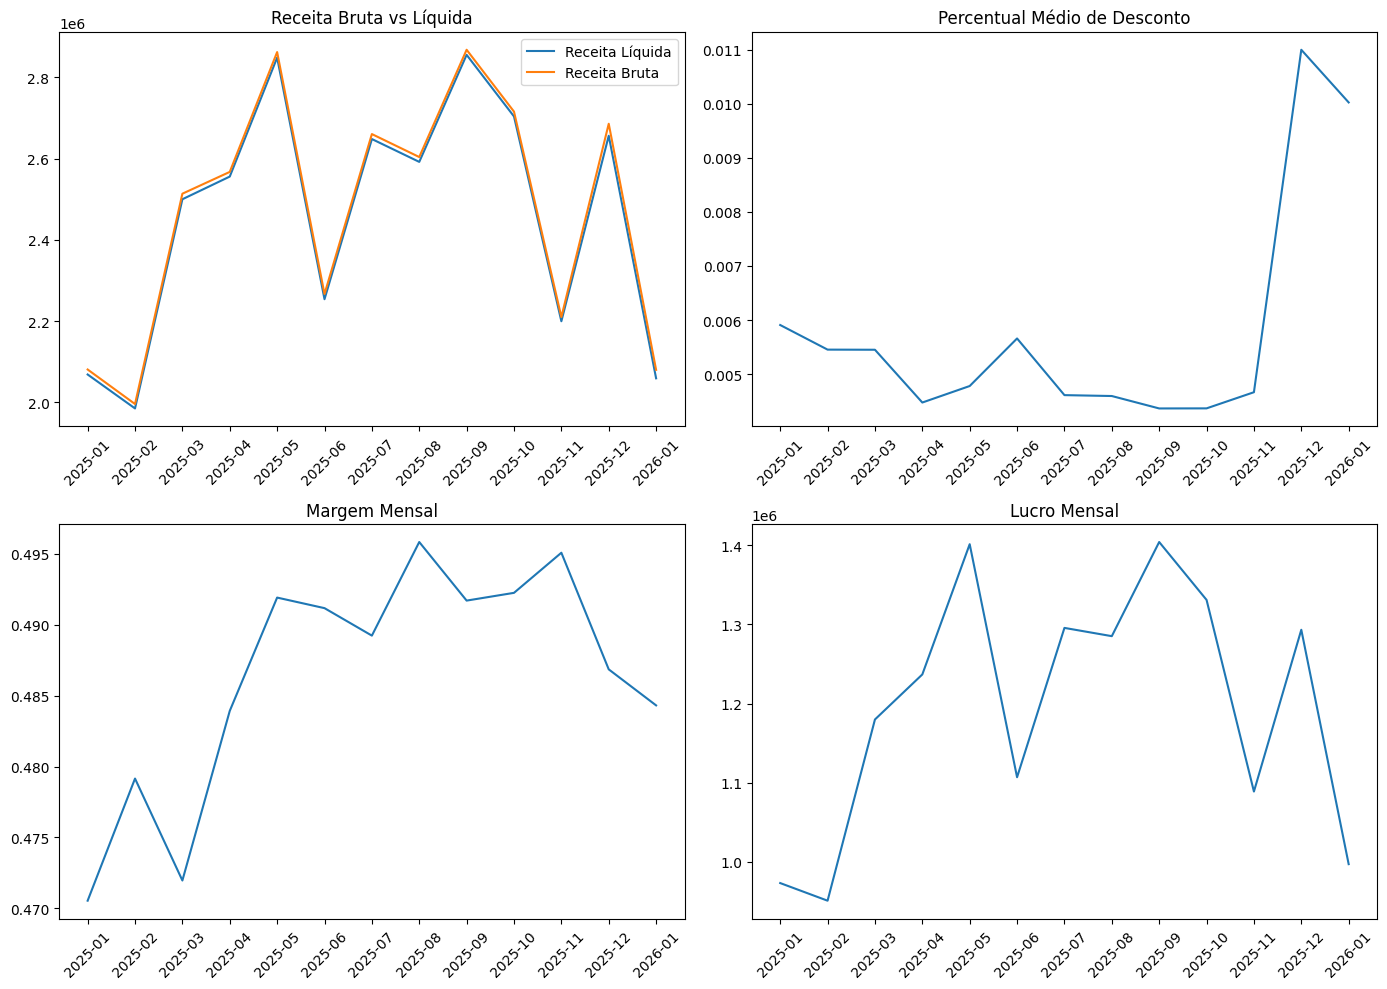

In [ ]:
# Preparar dados para o eixo x
x = mensal["ano_mes"].astype(str)

# Calcular margem se não existir
if "margem" not in mensal.columns:
	mensal["margem"] = mensal["lucro"] / mensal["valor_monetario_total"]

# Criar figura e matriz 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1️⃣ Receita Bruta vs Líquida
axes[0].plot(x, mensal["valor_monetario_total"], label="Receita Líquida")
axes[0].plot(x, mensal["faturamento_bruto"], label="Receita Bruta")
axes[0].set_title("Receita Bruta vs Líquida")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# 2️⃣ Percentual Médio de Desconto
axes[1].plot(x, mensal["percentual_desconto"])
axes[1].set_title("Percentual Médio de Desconto")
axes[1].tick_params(axis="x", rotation=45)

# 3️⃣ Margem Mensal
axes[2].plot(x, mensal["margem"])
axes[2].set_title("Margem Mensal")
axes[2].tick_params(axis="x", rotation=45)

# 4️⃣ Lucro Mensal
axes[3].plot(x, mensal["lucro"])
axes[3].set_title("Lucro Mensal")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Observa-se padrão sazonal de retração no mês de janeiro em ambos os anos analisados. Isso indica uma queda nas vendas após a alta temporada de datas comemorativas, o que é esperado.

É observado que o aumento nos descontos de dezembro de 2025 foi sucedido de uma alta nas vendas, o desconto pode ter atraído clientes, especialmente por causa de datas comemorativas. Porém, o alto desconto continuado em janeiro falhou em atrair clientes, então os descontos foram incapazes de reverter a tendência de queda de vendas da baixa temporada, criando até uma pequena diminuição de receita se comparado com janeiro do mês anterior. Essa diminuição de receita não é acompanhada pela diminuição no lucro, pois as margens de lucro estavam maiores, então não houve, teoricamente, prejuízos para a empresa.

# Como está a performance de vendas por filial ao longo dos meses (faturamento)? Quantos clientes distintos compraram por mês em cada filial?

### Criar dataframe com quantidades mensais desejadas:

In [60]:
filial_mensal = (
    base
    .groupby(["ano_mes", "filial_venda"])
    .agg({
        "valor_monetario_total": "sum",
        "lucro": "sum",
        "codigo_cliente": pd.Series.nunique
    })
    .reset_index()
)

filial_mensal.rename(columns={
    "valor_monetario_total": "receita_liquida",
    "codigo_cliente": "clientes_distintos"
}, inplace=True)

filial_mensal["ticket_medio"] = (
    filial_mensal["receita_liquida"] /
    filial_mensal["clientes_distintos"]
)

filial_mensal["ano_mes"] = filial_mensal["ano_mes"].astype(str)


### Visualizar Dataframe:

In [ ]:
display(filial_mensal)
filial_mensal.to_csv("../data/filial_mensal.csv", index=False)   

,ano_mes,filial_venda,receita_liquida,lucro,clientes_distintos,ticket_medio
0,2025-01,1,322338.90,141764.46,670,481.102836
1,2025-01,8,248371.99,116728.36,858,289.477844
2,2025-01,10,384835.29,183189.31,1180,326.131602
3,2025-01,11,105406.36,51363.27,414,254.604734
4,2025-01,14,429663.24,202534.21,1207,355.976172
...,...,...,...,...,...,...
86,2026-01,10,328743.65,164839.05,1060,310.135519
87,2026-01,11,301059.16,144606.04,899,334.882269
88,2026-01,14,321922.88,158787.67,997,322.891555
89,2026-01,16,132271.98,63855.02,383,345.357650


### Quantas filiais totais?

In [62]:
base["filial_venda"].nunique()


7

### Anáilise Inicial:

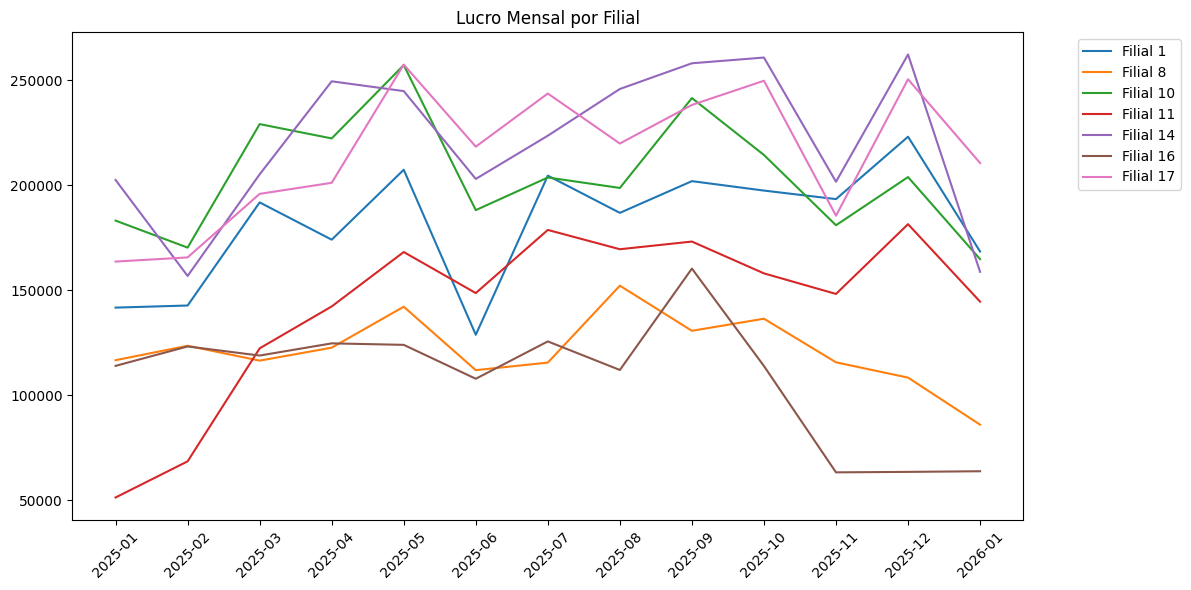

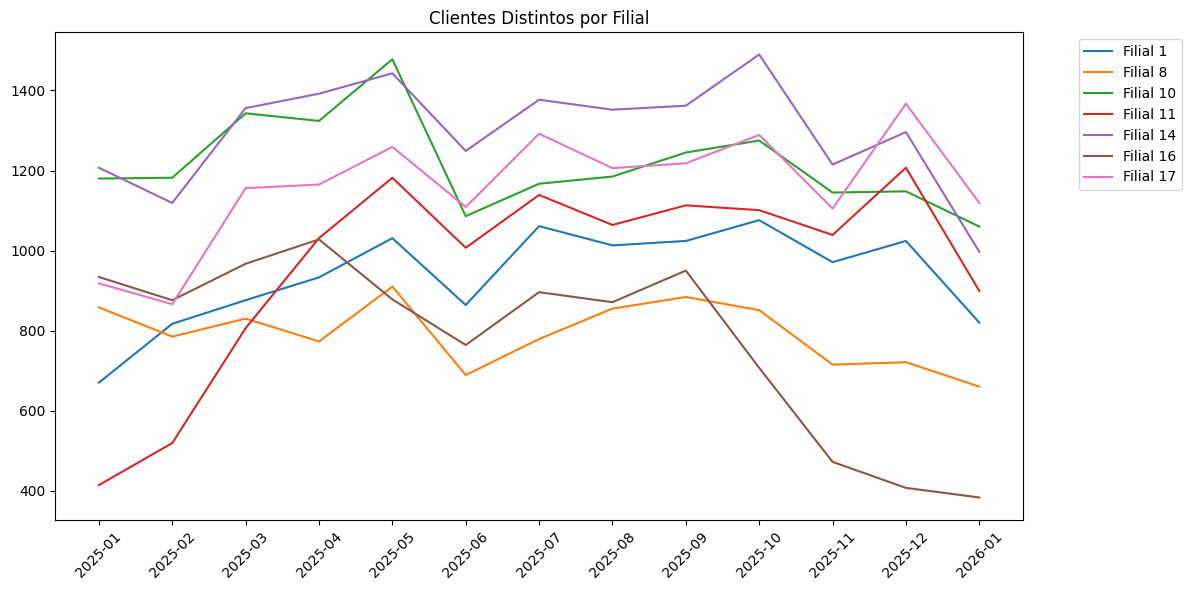

In [63]:
plt.figure(figsize=(12,6))

for filial in filial_mensal["filial_venda"].unique():
    dados = filial_mensal[filial_mensal["filial_venda"] == filial]
    plt.plot(dados["ano_mes"], dados["lucro"], label=f"Filial {filial}")

plt.xticks(rotation=45)
plt.title("Lucro Mensal por Filial")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))

for filial in filial_mensal["filial_venda"].unique():
    dados = filial_mensal[filial_mensal["filial_venda"] == filial]
    plt.plot(dados["ano_mes"], dados["clientes_distintos"], label=f"Filial {filial}")

plt.xticks(rotation=45)
plt.title("Clientes Distintos por Filial")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



As filiais 14, 10 e 17 apresentam o maior número de clientes.
OBS: a filial 16 tinha mais clientes diferentes que 17 até fevereiro de 2025, mas começou a perder clientes ao longo dos meses sequentes.

As filiais 10, 17 e 14 apresentaram o maior lucro ao longo dos meses, possivelmente por causa do número de clientes.
OBS: Não tão obstante do lucro dessas três filiais está o lucro da Filial 1, que apresenta menos clientes, porém esses clientes podem ser mais frequentes ou comprar coisas de maior valor, compensando no lucro.

### Análise por Filial:

In [ ]:
resumo_filial = (
    base
    .groupby("filial_venda")
    .agg({
        "valor_monetario_total": "sum",
        "lucro": "sum",
        "codigo_cliente": pd.Series.nunique
    })
    .reset_index()
)

resumo_filial.rename(columns={
    "valor_monetario_total": "receita_total",
    "codigo_cliente": "clientes_unicos"
}, inplace=True)

resumo_filial["ticket_medio"] = (
    resumo_filial["receita_total"] / resumo_filial["clientes_unicos"]
)

resumo_filial["lucro_por_cliente"] = (
    resumo_filial["lucro"] / resumo_filial["clientes_unicos"]
)

resumo_filial.sort_values("lucro", ascending=False)
resumo_filial.to_csv("../data/resumo_filial.csv", index=False)


Como esperado: As filiais 14 , 17 e 10 são as mais lucrativas.

Os dados sugerem uma explicação do lucro apresentado de cada filial, pois a quantidade clientes_unicos só é importante se o ticket_medio e lucro_por_cliente forem altos também.

A Filial 14 tem um bom valor dessas três quantidades; A Filial 17 tem menos clientes que a 14 e a 10, porém com faturamento por cliente maior; Já a Filial 10 tem comparativamente pouco faturamento por cliente porém é a que mais tem clientes diferentes comprando.

OBS: Como observado, a Filial 1 apresenta lucro comparável ao Top 3, e é possível concluir que se deve, de fato, ao faturamento por cliente elevado. 

### Análise adicional, Eficiência de cada Filial:

In [65]:
resumo_filial["margem"] = (
    resumo_filial["lucro"] /
    resumo_filial["receita_total"]
)

resumo_filial.sort_values("margem", ascending=False)


,filial_venda,receita_total,lucro,clientes_unicos,ticket_medio,lucro_por_cliente,margem
2,10,5363245.96,2658521.23,11369,471.742982,233.839496,0.495693
1,8,3189358.74,1578866.04,6827,467.168411,231.267913,0.495042
3,11,3768771.16,1855476.29,8301,454.014114,223.524430,0.492329
5,16,2919068.48,1415672.34,7355,396.882186,192.477545,0.484974
4,14,5928533.57,2873114.69,10984,539.742678,261.572714,0.484625
6,17,5787936.40,2800499.38,9237,626.603486,303.182784,0.483851
0,1,4970133.75,2362660.72,7980,622.823778,296.072772,0.475372


A margem de lucro é um indicativo da eficiência da estratégia de vendas de uma loja.

O ranking das filiais por margem é bem diferente do ranking por lucro, porém é de se notar que a diferença entre a maior e a menor margem é de somente 4%.

Isso indica que, apesar de pequenas flutuações, todas as filiais seguem a mesma estratégia de venda, muito provavelmente associada à empresa como um todo.

Isso significa que os fatores determinantes na diferenciação dos lucros entre as filiais são, realmente, a quantidade de clientes e o faturamento médio por cliente.

OBS: a margem calculada é uma margem bruta, pois não leva em conta custo fixo da filial, equipe, despesas regionais, etc..., portanto as conclusões tomadas são com base nos dados fornecidos.

# Como os descontos estão sendo aplicados por vendedor (percentual de desconto e valor total concedido)? Quem são os vendedores que mais concedem desconto proporcionalmente?

### Análise por vendedor:

In [66]:
resumo_vendedor = (
    base
    .groupby("codigo_vendedor")
    .agg({
        "valor_monetario_total": "sum",
        "lucro": "sum",
        "valor_desconto": "sum",
        "faturamento_bruto": "sum"
    })
    .reset_index()
)

resumo_vendedor["valor_desconto"] = abs(resumo_vendedor["valor_desconto"])

resumo_vendedor["percentual_desconto_medio"] = (
    resumo_vendedor["valor_desconto"] /
    resumo_vendedor["faturamento_bruto"]
)

resumo_vendedor.sort_values("percentual_desconto_medio", ascending=False)


,codigo_vendedor,valor_monetario_total,lucro,valor_desconto,faturamento_bruto,percentual_desconto_medio
37,16551,687197.76,343127.52,13610.90,700808.66,0.019422
3,438,496932.58,244223.97,9377.83,506310.41,0.018522
21,663,728502.07,357266.01,11261.82,739763.89,0.015224
49,16618,214891.68,110168.85,2501.62,217393.30,0.011507
44,16597,583095.63,292655.32,5881.04,588976.67,0.009985
15,563,839848.03,417148.40,8426.36,848274.39,0.009934
35,749,195146.79,97607.85,1884.94,197031.73,0.009567
25,696,604420.00,302133.88,5688.70,610108.70,0.009324
48,16604,382152.63,198138.39,3559.57,385712.20,0.009229
34,743,439674.18,205032.15,3968.63,443642.81,0.008946


### Ordenar por Lucro:

In [67]:
resumo_vendedor.sort_values("lucro", ascending=False)


,codigo_vendedor,valor_monetario_total,lucro,valor_desconto,faturamento_bruto,percentual_desconto_medio
30,724,1524676.42,746794.21,1204.49,1525880.91,0.000789
26,699,1436185.55,656896.88,7282.51,1443468.06,0.005045
10,521,1182818.63,588192.36,7189.96,1190008.59,0.006042
31,725,1200286.32,560907.69,3822.49,1204108.81,0.003175
38,16557,1120528.45,496612.44,883.63,1121412.08,0.000788
18,607,911477.60,459456.55,4326.28,915803.88,0.004724
13,548,926776.30,454896.01,6458.32,933234.62,0.006920
29,714,901975.18,436135.64,6032.48,908007.66,0.006644
4,468,867753.89,422473.61,1024.59,868778.48,0.001179
40,16574,830047.31,421538.75,6880.40,836927.71,0.008221


Os vendedores que mais sugerem descontos, proporcionalmente, são o 16551, o 438 e o 663. Entretanto, esses vendedores não são os que mais geram lucro. Isso pode ser justamentente devido aos descontos aplicados ou ao simples volume de vendas. Uma medida da margem de lucro é necessária para comparação da estratégia de venda de cada vendedor.

OBS: os vendedores com maior faturamento bruto são os com maior faturamento líquido.

### Análise da eficiência do vendedor:

In [ ]:
resumo_vendedor["margem"] = (
    resumo_vendedor["lucro"] /
    resumo_vendedor["valor_monetario_total"]
)

resumo_vendedor.sort_values("margem")
resumo_vendedor.to_csv("../data/resumo_vendedor.csv", index=False)


Existe uma diferença máxima de 20% entre as margens de lucro de dois vendedores. Isso implica que os vendedores têm certa autonomia na hora da venda, porém, há, certamente, limites impostos por políticas de venda da empresa.

Nota-se, também, que os vendedores com maior desconto percentual não são os que apresentam menor margem de lucro. Por exemplo, o vendedor 16551 (percentual de desconto ~2%) tem uma margem de lucro de 0.49314, que é maior que o vendedor 378 (percentual de desconto ~0.05%) com margem de 0.443072

Essa observação implica que há diversos fatores que afetam a capacidade de faturamento total de cada vendedor. Se um vendedor trabalha com produtos naturalmente mais rentáveis, ele pode conceder desconto e ainda manter margem superior.

Portanto, o maior lucro será gerado pelo vendedor que tiver o melhor mix de qualidades de produtos.

# Como está a participação de cada família de produtos no faturamento total? Quais são as Top 5 famílias de produtos mais relevantes?

### Analisar famílias de produtos para verificar o impacto do mix:

In [ ]:
familia_resumo = (
    base
    .groupby("descricaofamilia")
    .agg({
        "valor_monetario_total": "sum",
        "lucro": "sum"
    })
    .reset_index()
)

familia_resumo["margem"] = (
    familia_resumo["lucro"] /
    familia_resumo["valor_monetario_total"]
)

familia_resumo.sort_values("margem", ascending=False)
familia_resumo.to_csv("../data/familia_resumo.csv", index=False)


Com uma diferença máxima de ~125% entre a rentabilidade de duas famílias, os dados sugerem um impacto importante que o tipo de produto vendido potencialmente causa no faturamento.

Agora quero associar os 5 vendedores com maior lucro com as famílias dos produtos que eles venderam.

### Analisando o impacto das familias de produtos no faturamento dos vendedores:

Criando dataset com a informação das duas famílias de produtos mais vendidas por cada um dos 5 maiores vendedores.

In [ ]:
top5_vendedores = (
    resumo_vendedor
    .sort_values("lucro", ascending=False)
    .head(5)["codigo_vendedor"]
    .tolist()
)

top5_base = base[base["codigo_vendedor"].isin(top5_vendedores)]

mix_top5 = (
    top5_base
    .groupby(["codigo_vendedor", "descricaofamilia"])
    .agg({
        "valor_monetario_total": "sum",
        "lucro": "sum"
    })
    .reset_index()
)

mix_top5["participacao_receita"] = (
    mix_top5["valor_monetario_total"] /
    mix_top5.groupby("codigo_vendedor")["valor_monetario_total"].transform("sum")
)

top2_familias = (
    mix_top5
    .sort_values(
        ["codigo_vendedor", "participacao_receita"],
        ascending=[True, False]
    )
    .groupby("codigo_vendedor")
    .head(2)
    .reset_index(drop=True)
)

top2_familias
top2_familias.to_csv("../data/top2_familias.csv", index=False)


Os 4 vendedores com maior lucro vendem muito de Small Appliances, que é uma família bem rentável.

O vendedor 521 e o 724 vendem mais das mesmas famílias (Small Appliances e Indoor Plants), famílias dentre as mais rentáveis. A diferença de lucro entre si deve depender da movimentação de clientes da filial ou da performance individual de vendas.

Diferente do top 4, o vendedor 16557 conseguiu o quinto maior faturamento dentre os vendedores vendendo mais de produtos pouco rentáveis, comparativamente. Isso pode indicar alguma estratégia de vendas individual eficiente ou o mix de produtos geral bem balanceado.

### Analisando as famílias que geram mais receita total:

In [ ]:
familia_receita = (
    base
    .groupby("descricaofamilia")
    .agg({
        "valor_monetario_total": "sum"
    })
    .reset_index()
)

# calcular participação percentual
total_receita = familia_receita["valor_monetario_total"].sum()

familia_receita["participacao_receita"] = (
    familia_receita["valor_monetario_total"] / total_receita
)

# ordenar da maior para menor
familia_receita = familia_receita.sort_values(
    "participacao_receita",
    ascending=False
)

# calcular participação acumulada
familia_receita["participacao_acumulada"] = (
    familia_receita["participacao_receita"].cumsum()
)

familia_receita
familia_receita.to_csv("../data/familia_receita.csv", index=False)


Quantas famílias no total?

In [72]:
base["descricaofamilia"].nunique()


60

Como esperado, após a analise por vendedores, as famílias com mais participação na receita total são Small Appliances e Indoor Plants.

Também é possível explicar, parcialmente, o alto lucro do vendedor 16557, pois Streaming Services e Kitchenware estão no Top 10 famílias com maior participação de receita. Isso pode indicar que o volume de vendas desses produtos compensa a baixa margem.

É de se notar que 50% da receita total da empresa vem de somente um sexto das famílias de produtos. Portanto, a empresa apresenta concentração moderada de receita em poucas famílias, sugerindo dependência estrutural dessas categorias.

# Quais são os Top 5 produtos mais relevantes dentro de cada família (em faturamento e/ou lucro unitário total)?

Entender quais produtos sustentam o desempenho de cada
família e identificar possíveis dependências concentradas em poucos
itens.

### Top 5 produtos por faturamento dentro de cada família:

In [ ]:
produto_familia = (
    base
    .groupby(["descricaofamilia", "descricaoproduto"])
    .agg({
        "valor_monetario_total": "sum",
        "lucro": "sum"
    })
    .reset_index()
)

# calcular participação dentro da própria família
produto_familia["participacao_familia"] = (
    produto_familia["valor_monetario_total"] /
    produto_familia.groupby("descricaofamilia")["valor_monetario_total"].transform("sum")
)

# ordenar
produto_familia = produto_familia.sort_values(
    ["descricaofamilia", "valor_monetario_total"],
    ascending=[True, False]
)

# pegar top 5 de cada família
top5_produtos_familia = (
    produto_familia
    .groupby("descricaofamilia")
    .head(5)
    .reset_index(drop=True)
)

top5_produtos_familia.to_csv("../data/top5_produtos_familia.csv", index=False)
top5_produtos_familia


,descricaofamilia,descricaoproduto,valor_monetario_total,lucro,participacao_familia
0,Arts & Crafts,Arts & Crafts Wave Travel Dourado #6585713F,267622.96,116209.64,0.337426
1,Arts & Crafts,Essential Arts & Crafts Premium Vermelho #00B4...,126628.97,55754.65,0.159657
2,Arts & Crafts,Arts & Crafts Select Active Prata #16B4DB45,117731.35,54212.95,0.148439
3,Arts & Crafts,Arts & Crafts Boost Sport Verde #D28DB4A7,100142.57,52983.89,0.126262
4,Arts & Crafts,Arts & Crafts Pro Roxo Tam.GG #5E9DD627,63311.94,33071.62,0.079825
...,...,...,...,...,...
288,Wall Decor,Wall Decor Active Home Branco #FC3B7223,67568.09,30504.11,0.235827
289,Wall Decor,Wall Decor Essential Plus Grafite #65921196,41350.40,18572.84,0.144322
290,Wall Decor,Pack Wall Decor Urban Cinza #0F41A74C,39384.30,17740.55,0.137459
291,Wall Decor,Wall Decor Lite Air Cinza #DCB0CE91,31664.21,14134.61,0.110515


### Dependência percentual de cada família nos top 5 produtos no lucro final:

In [ ]:
top5_dependencia = (
    top5_produtos_familia
    .groupby("descricaofamilia")
    ["participacao_familia"].sum()
    .reset_index()
    .rename(columns={"participacao_familia": "participacao_top5"})
)

top5_dependencia.to_csv("../data/top5_dependencia.csv", index=False)
top5_dependencia.sort_values("participacao_top5", ascending=False)


,descricaofamilia,participacao_top5
2,Bathroom Fixtures,1.000000
21,Hobbies,1.000000
27,Kitchen Appliances,1.000000
24,Home Office Furniture,1.000000
48,Software,1.000000
31,Lighting,0.998022
19,Gaming Consoles,0.993688
36,Musical Accessories,0.985620
42,Painting Supplies,0.979005
1,Bakeware,0.967235


Analisando as tabelas construídas, é possível separar as famílias em três categorias: Completamente dependentes; parcialmente dependentes; e praticamente independentes.

As famílias completamente dependendes nos seus top 5 produtos são as que têm 5 ou menos produtos no total. Para essas famílias, quaiquer flutuações nos preços ou falha temporária no suprimento dos produtos afetarão o lucro do período significativamente.

As famílias parcialmente dependentes são as que possuem mais de 5 produtos no total, porém mais de 40% de dependencia de lucro nesses produtos. Flutuações temporárias são prováveis de afetar o lucro significativamente, porém medidas estratégicas pela empresa podem diminuir os prejuízos.

As famílias praticamente independentes são as com mais de 5 produtos no total, mas com uma dependencia de menos de 40% desses produtos no lucro. Flutuações temporárias são improváveis de afetar o lucro signicativamente e medidas estratégicas pela empresa podem, potencialmente, evitar quaiquer prejuízos.

OBS.1: Small Appliances e Indoor Plants, as famílias que mais contribuem para a receita total, são também as com menos dependências em produtos específicos, implicando que a estabilidade na venda de produtos dessas famílias é um fator chave na rentabilidade total.

OBS.2: Outdoor Gear e Toilets, que estão no top 5 de famílias que mais geram receita (top 5 somam 35% de participação acumulada), têm dependência parcial nos seus respectivos top 5 produtos. Então, a empresa deve sempre manter estratégias para diminuir o prejuízo na receita total, em caso de flutuações de mercado.

### Dependência de famílias em produtos específicos:

In [ ]:
top1_produto_familia = (
    top5_produtos_familia
    .sort_values(
        ["descricaofamilia", "valor_monetario_total"],
        ascending=[True, False]
    )
    .groupby("descricaofamilia")
    .head(1)
    .reset_index(drop=True)
)

top1_produto_familia.sort_values("participacao_familia", ascending=False)
top1_produto_familia.to_csv("../data/top1_produto_familia.csv", index=False)


Dentre as famílias, as que têm uma dependência de mais de 50% em somente um produto são: Bathroom Fixtures;Software;Bakeware;Home Office Furniture;Electronics;Showers & Tubs;Musical Accessories;Cookware;Kitchen Appliances. Essas famílias não são as que geram mais receita, porém devem ser monitoradas para não haver prejuízos.

# Quais combinações de famílias de produtos apresentam maior afinidade no comportamento de compra dos clientes (família–família), no estilo “clientes que compraram X tendem a comprar Y”?

Para identificar afinidade entre famílias de produtos, primeiro transformamos o histórico de compras em uma matriz cliente × família. Cada linha representa um cliente e cada coluna uma família de produtos. O valor da célula é binário: 1 se o cliente já comprou aquela família em qualquer momento do histórico (mesmo em contratos diferentes) e 0 caso contrário. Essa estrutura elimina o efeito de quantidade ou valor gasto e foca apenas no comportamento de compra — ou seja, se houve ou não relação entre cliente e família. A partir dessa matriz binária, calculamos a coocorrência entre famílias multiplicando a matriz transposta por ela mesma. O resultado é uma nova matriz família × família, em que cada célula indica quantos clientes compraram ambas as famílias.

No entanto, coocorrência sozinha pode ser enganosa, pois famílias muito populares naturalmente aparecerão juntas com maior frequência. Para corrigir esse viés utilizamos o Lift, que mede a associação relativa entre duas famílias. O Lift compara a probabilidade observada de dois eventos ocorrerem juntos com a probabilidade esperada caso fossem independentes. Formalmente, é a razão entre 
P(X∩Y) e 
P(X)×P(Y). Se o Lift for maior que 1, existe afinidade positiva — clientes que compram X tendem, acima do esperado pelo acaso, a comprar Y. Se for igual a 1, não há relação relevante; se menor que 1, a combinação ocorre menos do que seria esperado. Assim, o Lift permite identificar padrões reais de comportamento e fundamentar estratégias de cross-sell, bundles e recomendações personalizadas com base estatística, e não apenas em volume bruto de vendas.

### Criar matriz Cliente-Família:

In [76]:
cliente_familia = (
    base
    .groupby(["codigo_cliente", "descricaofamilia"])
    .size()
    .unstack(fill_value=0)
)

# transformar em binário (comprou ou não comprou)
cliente_familia = (cliente_familia > 0).astype(int)
cliente_familia


descricaofamilia,Arts & Crafts,Bakeware,Bathroom Fixtures,Bedding,Bedroom Furniture,Books,Carpet & Rugs,Ceiling Lights,Clothing,Collectibles,...,Sports Equipment,Sports Memorabilia,Stamps & Coins,Streaming Services,Tile Flooring,Toilets,Toys,Utensils,Video Games,Wall Decor
codigo_cliente,,,,,,,,,,,,,,,,,,,,,
12.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
42.0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
63.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
70.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
107.0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939372.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
939373.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
939375.0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Calcular matriz de co-ocorrência:

In [ ]:

coocorrencia = np.dot(cliente_familia.T, cliente_familia)

coocorrencia_df = pd.DataFrame(
    coocorrencia,
    index=cliente_familia.columns,
    columns=cliente_familia.columns
)

coocorrencia_df.to_csv("../data/coocorrencia_familias.csv")
coocorrencia_df

descricaofamilia,Arts & Crafts,Bakeware,Bathroom Fixtures,Bedding,Bedroom Furniture,Books,Carpet & Rugs,Ceiling Lights,Clothing,Collectibles,...,Sports Equipment,Sports Memorabilia,Stamps & Coins,Streaming Services,Tile Flooring,Toilets,Toys,Utensils,Video Games,Wall Decor
descricaofamilia,,,,,,,,,,,,,,,,,,,,,
Arts & Crafts,123,15,11,4,2,9,4,9,8,6,...,4,1,11,4,1,14,13,4,1,1
Bakeware,15,2115,167,19,95,493,25,62,376,152,...,25,18,76,6,27,101,116,35,32,34
Bathroom Fixtures,11,167,893,9,21,121,7,32,64,57,...,10,6,45,2,5,52,73,11,11,15
Bedding,4,19,9,277,10,8,6,12,10,6,...,17,3,13,7,3,30,15,7,5,4
Bedroom Furniture,2,95,21,10,1984,210,20,23,202,54,...,68,11,16,4,28,167,46,27,20,26
Books,9,493,121,8,210,4868,19,59,1035,648,...,32,15,49,2,34,179,93,41,30,79
Carpet & Rugs,4,25,7,6,20,19,587,18,26,23,...,17,9,7,2,17,51,25,26,29,14
Ceiling Lights,9,62,32,12,23,59,18,770,47,82,...,23,12,29,2,15,53,41,21,17,11
Clothing,8,376,64,10,202,1035,26,47,4305,183,...,40,22,47,1,35,159,80,62,43,30


### Calcular afinidade real (Lift):

Matriz de lift principal:

In [ ]:
n_clientes = cliente_familia.shape[0]

frequencia = cliente_familia.sum() / n_clientes

lift = pd.DataFrame(index=frequencia.index, columns=frequencia.index)

for f1 in frequencia.index:
    for f2 in frequencia.index:
        p_xy = coocorrencia_df.loc[f1, f2] / n_clientes
        p_x = frequencia[f1]
        p_y = frequencia[f2]
        lift.loc[f1, f2] = p_xy / (p_x * p_y)

lift = lift.astype(float)
lift.to_csv("../data/lift_familias.csv")

Lift filtrado por número de clientes para boa estatística:

In [ ]:
lift.index.name = None
lift.columns.name = None


lift_unstacked = (
    lift
    .where(np.triu(np.ones(lift.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

lift_unstacked.columns = ["familia_1", "familia_2", "lift"]

cooc_unstacked = (
    coocorrencia_df
    .rename_axis(index="familia_1", columns="familia_2")
    .where(np.triu(np.ones(coocorrencia_df.shape), k=1).astype(bool))
    .stack()
    .reset_index(name="clientes")
)

lift_unstacked = lift_unstacked.merge(
    cooc_unstacked,
    on=["familia_1", "familia_2"],
    how="left"
)

lift_filtrado = lift_unstacked[lift_unstacked["clientes"] >= 300]

lift_filtrado.sort_values("clientes", ascending=False)
lift_filtrado.to_csv("../data/lift_filtrado_familias.csv", index=False)
lift_filtrado

,familia_1,familia_2,lift,clientes
62,Bakeware,Books,2.792183,493.0
65,Bakeware,Clothing,2.408032,376.0
80,Bakeware,Home Decor,8.917147,566.0
91,Bakeware,Mirrors,1.862001,342.0
97,Bakeware,Outdoor Gear,3.943128,379.0
98,Bakeware,Outdoor Plants,2.441632,346.0
287,Books,Clothing,2.879881,1035.0
288,Books,Collectibles,3.581983,648.0
290,Books,Cookware,3.571652,407.0
302,Books,Home Decor,2.231449,326.0


Esses dados podem, agora, ser analisados de maneira estatísticamente confiável.

É percebido um lift alto para uma grande quantidade de clientes quando a família Books é envolvida (Books - Outdoor Plants;Books - Lamps;Books - Mirrors;Books - Clothing). Isso sugere que Books é uma boa família ponte, ou seja, se um cliente compra um livro de jardinagem é provável que compre um produto de Outdoor Plants também, ou vice-versa.

Produtos de mesma categoria também são bem correlacionados. Por exemplo, na categoria Casa e Decoração, relações entre famílias de produtos (Lamps - Mirrors, Indoor Plants - Small Appliances, Lamps - Outdoor Plants, etc...) surgem.

Também há evidência nos dados de combinações de famílias inesperadas, como Clothing - Outdoor Plants, Indoor Plants - Sound Equipment.

O ideal para fazer proveito dessas correlações seria, antes, testar a validade dessa análise. Um teste A/B, onde A é um grupo de clientes normais e B é um grupo que foi sujeito a recomendações de pares baseado na famílias dos produtos que estavam comprando (comprando Clothing -> recomendando Books, por exemplo). Ao medir a diferença de lucro gerado por cada grupo é possível atribuir um valor à essa estratégia.

### Visualização da Rede de Associações entre Famílias

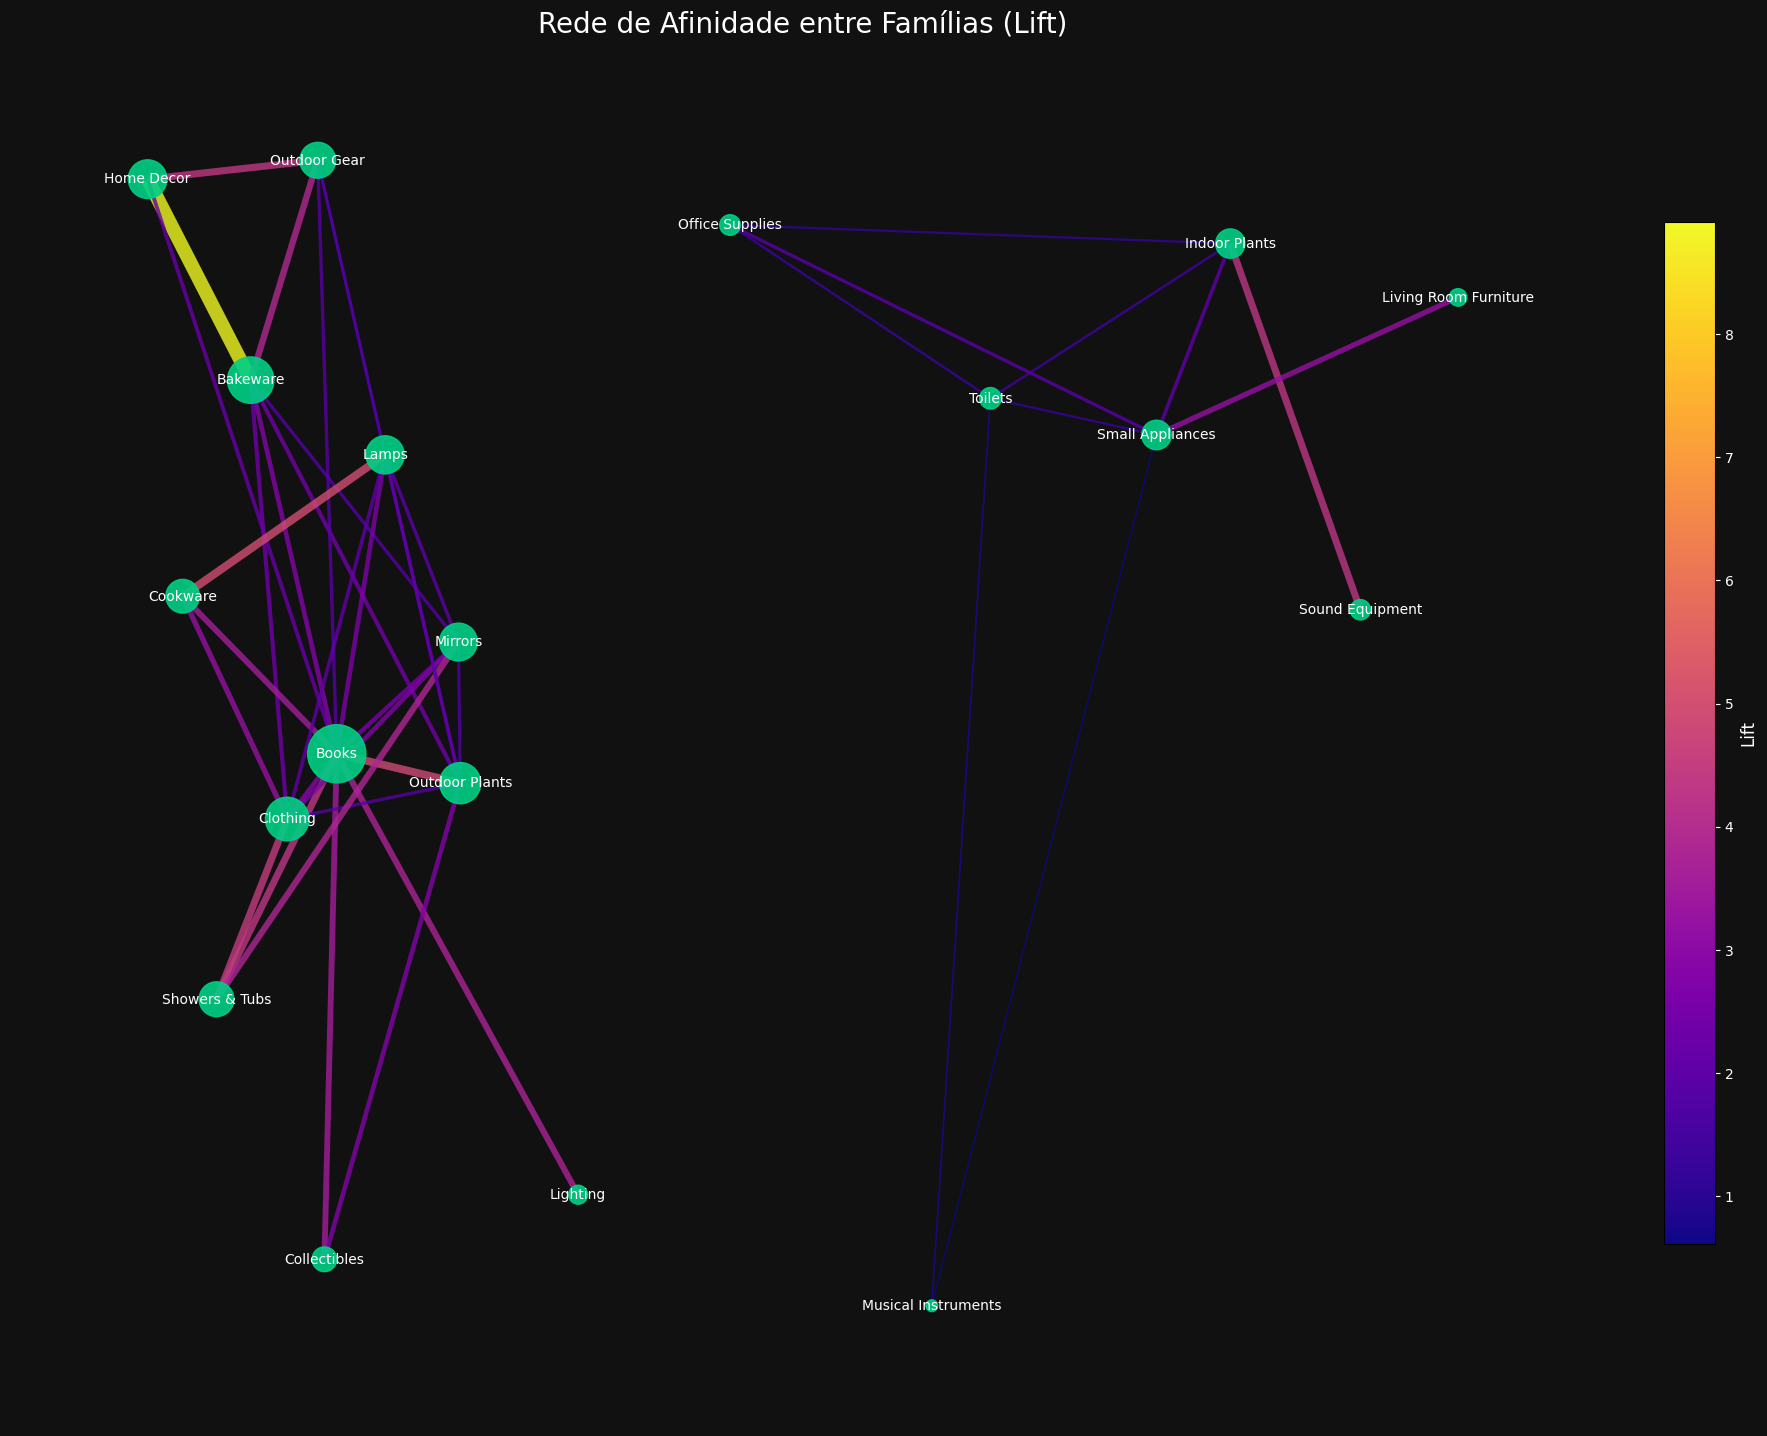

In [ ]:
# ===============================
# Criar grafo
# ===============================
G = nx.Graph()

# Adicionar nós
familias_unicas = pd.unique(lift_filtrado[['familia_1', 'familia_2']].values.ravel())
G.add_nodes_from(familias_unicas)

# Adicionar arestas com atributo 'weight' = lift
for _, row in lift_filtrado.iterrows():
    G.add_edge(row["familia_1"], row["familia_2"], weight=row["lift"])

# ===============================
# Layout automático
# ===============================
pos = nx.spring_layout(G, k=0.999, seed=42)  # k controla a distância entre nós

# ===============================
# Node size proporcional à soma de Lift conectado
# ===============================
node_weights = {node: sum(d['weight'] for _,_,d in G.edges(node, data=True)) for node in G.nodes()}
node_sizes = [node_weights[n]*50 for n in G.nodes()]  # multiplicador ajustável

# ===============================
# Edge color e grossura baseado no Lift
# ===============================
edges = G.edges(data=True)
edge_weights = [d['weight'] for _,_,d in edges]

# Normalização para cores e largura
cmap = plt.cm.plasma
norm = plt.Normalize(min(edge_weights), max(edge_weights))
edge_colors = [cmap(norm(w)) for w in edge_weights]

# Ajuste da grossura proporcional (normaliza para 1-10)
min_width, max_width = 1, 10
w_min, w_max = min(edge_weights), max(edge_weights)
edge_widths = [min_width + (w - w_min)/(w_max - w_min)*(max_width-min_width) for w in edge_weights]

# ===============================
# Plot com fundo dark
# ===============================
fig, ax = plt.subplots(figsize=(22,18), facecolor="#111111")
ax.set_facecolor("#111111")

# Desenhar nós
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color="#00D084",
    alpha=0.9,
    ax=ax
)

# Desenhar arestas
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.8,
    ax=ax
)

# Desenhar labels
nx.draw_networkx_labels(
    G, pos,
    font_size=10,
    font_color="white",
    ax=ax
)

# Título
ax.set_title("Rede de Afinidade entre Famílias (Lift)", fontsize=20, color="white")

# Remover eixos
ax.axis("off")

# Barra de cores para Lift
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Lift", color="white", fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.savefig("../data/rede_lift_familias.png", dpi=600, facecolor=fig.get_facecolor())
plt.show()


Observando a rede construída, é possível ver dois clusters principais de conexões com mais de 300 clientes. Um cluster centrado em Books e Bakeware e outro centrado em Small Appliances.

As conexões de lift alto do Small Appliances Cluster podem ser classificadas como Infraestruturação de Casa, evidenciando conexões entre Small Appliances e Indoor Plants, Livingroom Furniture e Office Supplies. Isso pode ser usado em campanhas, bundles e recomendações a clientes.

As conexões de lift alto de Books podem ser estudadas para fazer uso de Bundles e recomendações para clientes comprando roupas, panelas, etc... 

As conexões de lift alto de Bakeware são inesperadas, mas talvez implique que, se colocar produtos inesperadamente correlacionados em promoção, por exemplo, pode haver um salto em vendas dos mesmos.

Em todos os casos, um teste A/B é recomendado para testar a aplicação real dessa análise estatística.